In [ ]:
import subprocess
subprocess.run(["pip", "install", "-q",
    "silero-vad", "datasets", "transformers",
    "accelerate", "evaluate", "scikit-learn", "torchaudio"
])


all done installing


In [ ]:
# CHUNK 1- load the dataset and clean the transcript annotations

import re
import json
from datasets import load_dataset, Audio

def parse_transcript(text):
    clean_words, disfluent_indices = [], []
    tokens = re.findall(r'\{[^}]+\}|\S+', text)
    for token in tokens:
        m = re.match(r'\{[FD](.*?)\}', token)
        if m:
            for word in m.group(1).strip().split():
                disfluent_indices.append(len(clean_words))
                clean_words.append(word)
        else:
            word = re.sub(r'[\[\]+]', '', token).strip()
            if word:
                clean_words.append(word)
    return clean_words, disfluent_indices

def clean_disfluency_tags(batch):
    clean_words, disfluent_indices = parse_transcript(batch["transcript_annotated"])
    return {
        "text_cleaned"     : " ".join(clean_words),
        "total_words"      : len(clean_words),
        "disfluent_indices": json.dumps(disfluent_indices),
    }

SR = 16000
print("loading dataset...")
ds_train = load_dataset("amaai-lab/DisfluencySpeech", split="train").cast_column("audio", Audio(sampling_rate=SR))
ds_test  = load_dataset("amaai-lab/DisfluencySpeech", split="test").cast_column("audio",  Audio(sampling_rate=SR))

proc_train = ds_train.map(clean_disfluency_tags)
proc_test  = ds_test.map(clean_disfluency_tags)
print(f"train: {len(proc_train)} clips   test: {len(proc_test)} clips")

loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/438M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/250 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

train: 4500 clips   test: 250 clips


In [ ]:
# CHUNK 2- set up silero-vad and the severity score formula

import torch
import numpy as np

print("loading silero VAD...")
try:
    from silero_vad import load_silero_vad, get_speech_timestamps as _gst
    vad_model = load_silero_vad()
    get_speech_timestamps = _gst
    print("using silero-vad pip version")
except ImportError:
    vad_model, vad_utils = torch.hub.load(
        'snakers4/silero-vad', 'silero_vad', force_reload=False, onnx=False
    )
    get_speech_timestamps = vad_utils[0]
    print("using silero-vad torch.hub version")

# speaking speed constants
TARGET_WPS   = 2.75
RUSH_WPS     = 4.5
LONG_PAUSE_S = 0.8
CHUNK_SIZE   = SR * 5

WEIGHTS = np.array([0.30, 0.25, 0.20, 0.15, 0.10], dtype=np.float64)


def compute_severity(chunk_audio, words_in_chunk):
    """
    takes a 5-second audio chunk and estimates how unstable the speaking pace is
    returns a score from 0.0 (stable) to 1.0 (very unstable)
    also returns a debug dict so we can see what the individual signals looked like
    """

    chunk_tensor = torch.from_numpy(chunk_audio.astype(np.float32))

    try:
        segments = get_speech_timestamps(
            chunk_tensor,
            vad_model,
            sampling_rate = SR,
            threshold     = 0.5,
        )
    except Exception:
        return 0.0, {"note": "vad_failed"}

    if len(segments) == 0:
        return 0.0, {"note": "no_speech"}


    def to_sec(val):
        v = float(val)
        return v if v <= 5.0 else v / SR

    burst_starts  = np.array([to_sec(s['start']) for s in segments], dtype=np.float64)
    burst_ends    = np.array([to_sec(s['end'])   for s in segments], dtype=np.float64)
    burst_lengths = np.maximum(burst_ends - burst_starts, 1e-6)
    total_speech  = burst_lengths.sum()

    # calculate the pause duration between each speech burst
    # if there's only one burst there are no gaps
    if len(segments) > 1:
        gaps = np.maximum(burst_starts[1:] - burst_ends[:-1], 0.0)
    else:
        gaps = np.array([0.0], dtype=np.float64)

    # estimate words per second for each burst
    if total_speech > 0 and words_in_chunk > 0:
        words_per_burst = (burst_lengths / total_speech) * words_in_chunk
        wps_per_burst   = words_per_burst / burst_lengths
    else:
        wps_per_burst = np.zeros(len(burst_lengths), dtype=np.float64)

    mean_wps = float(wps_per_burst.mean())

    # SIGNAL 1- pause CoV  how consistent are the gap lengths?
    if len(gaps) > 1 and gaps.mean() > 1e-9:
        pause_cov = float(np.clip(gaps.std() / gaps.mean(), 0.0, 1.0))
    else:
        pause_cov = 0.0

    # SIGNAL 2- max pause  is there one very long silence in this chunk?
    max_pause_norm = float(np.clip(gaps.max() / LONG_PAUSE_S, 0.0, 1.0))

    # SIGNAL 3 - rush ratio  what fraction of bursts are above 4.5 WPS?
    rush_ratio = float((wps_per_burst > RUSH_WPS).mean())

    # SIGNAL 4- WPS deviation  how far off is the average speed from 2.75 WPS?
    wps_deviation = float(np.clip(abs(mean_wps - TARGET_WPS) / TARGET_WPS, 0.0, 1.0))

    # SIGNAL 5- burst CoV  are the speech chunks consistent in length?
    if len(burst_lengths) > 1 and burst_lengths.mean() > 1e-9:
        burst_cov = float(np.clip(burst_lengths.std() / burst_lengths.mean(), 0.0, 1.0))
    else:
        burst_cov = 0.0

    # weighted sum of all 5 signals this is the final severity score
    signals  = np.array([pause_cov, max_pause_norm, rush_ratio, wps_deviation, burst_cov])
    severity = float(np.clip(float((WEIGHTS * signals).sum()), 0.0, 1.0))

    debug = {
        "n_bursts"      : int(len(segments)),
        "mean_wps"      : round(mean_wps, 3),
        "pause_cov"     : round(pause_cov, 3),
        "max_pause_norm": round(max_pause_norm, 3),
        "rush_ratio"    : round(rush_ratio, 3),
        "wps_deviation" : round(wps_deviation, 3),
        "burst_cov"     : round(burst_cov, 3),
    }
    return severity, debug


dummy  = np.zeros(CHUNK_SIZE, dtype=np.float32)
s, d   = compute_severity(dummy, 10)
print(f"sanity check on silence → score={s:.3f}  type={type(s).__name__}")
print("VAD and severity formula are working")

loading silero VAD...
using silero-vad pip version
sanity check on silence → score=0.000  type=float
VAD and severity formula are working


In [ ]:
# CHUNK 3- chop clips into 5s chunks and generate severity labels

import os
import gc
import json
import numpy as np
from transformers import AutoFeatureExtractor
from datasets import Dataset, DatasetDict, concatenate_datasets

BATCH_SIZE = 400
SAVE_DIR   = "/content/pace_cache"
os.makedirs(SAVE_DIR, exist_ok=True)

feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/wav2vec2-base")


def chop_label_pace(sample):
    audio       = np.array(sample["audio"]["array"], dtype=np.float32)
    total_words = int(sample["total_words"])
    n_chunks    = max(1, int(np.ceil(len(audio) / CHUNK_SIZE)))

    ivs, ams, scores, debugs = [], [], [], []

    for chunk_idx, start in enumerate(range(0, len(audio), CHUNK_SIZE)):
        chunk = audio[start : start + CHUNK_SIZE]
        if len(chunk) < CHUNK_SIZE:
            chunk = np.pad(chunk, (0, CHUNK_SIZE - len(chunk)))

        words_in_chunk = max(1, round(total_words / n_chunks))

        severity, debug = compute_severity(chunk, words_in_chunk)

        feats = feature_extractor(
            [chunk],
            sampling_rate = SR,
            max_length    = CHUNK_SIZE,
            truncation    = True,
            padding       = "max_length",
            return_tensors= "np"
        )

        ivs.append(feats["input_values"][0].astype(np.float16))
        if "attention_mask" in feats:
            ams.append(feats["attention_mask"][0])

        scores.append(float(severity))
        debugs.append(json.dumps(debug))

    del audio
    return ivs, ams, scores, debugs


def process_split(split_ds, split_name):
    batch_paths = []
    total_clips = len(split_ds)

    for batch_start in range(0, total_clips, BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, total_clips)
        bn        = batch_start // BATCH_SIZE
        print(f"  {split_name} batch {bn+1}: clips {batch_start}–{batch_end} of {total_clips}")

        b_iv, b_am, b_sc, b_db = [], [], [], []
        for i in range(batch_start, batch_end):
            ivs, ams, scs, dbs = chop_label_pace(split_ds[i])
            b_iv.extend(ivs)
            b_am.extend(ams)
            b_sc.extend(scs)
            b_db.extend(dbs)

        data_dict = {
            "input_values"  : b_iv,
            "severity_score": b_sc,
            "pace_debug"    : b_db,
        }
        if b_am:
            data_dict["attention_mask"] = b_am

        batch_ds  = Dataset.from_dict(data_dict)
        save_path = os.path.join(SAVE_DIR, f"{split_name}_batch_{bn:04d}")
        batch_ds.save_to_disk(save_path)
        batch_paths.append(save_path)

        del b_iv, b_am, b_sc, b_db, batch_ds, data_dict
        gc.collect()

    print(f"  merging {len(batch_paths)} batches for {split_name}...")
    from datasets import load_from_disk
    full_ds = concatenate_datasets([load_from_disk(p) for p in batch_paths])

    scores = np.array(full_ds["severity_score"], dtype=np.float32)
    print(f"  {split_name}: {len(split_ds)} clips → {len(full_ds)} chunks")
    print(f"    mean={scores.mean():.3f}  std={scores.std():.3f}  min={scores.min():.3f}  max={scores.max():.3f}")
    print(f"    stable (<0.3): {(scores < 0.3).sum()}  moderate (0.3-0.6): {((scores >= 0.3) & (scores < 0.6)).sum()}  unstable (>0.6): {(scores >= 0.6).sum()}")
    return full_ds


print("\nrunning feature extraction and generating pace labels...")
train_encoded = process_split(proc_train, "train")
test_encoded  = process_split(proc_test,  "test")

split_ds = DatasetDict({"train": train_encoded, "test": test_encoded})
print(f"\ntrain: {len(split_ds['train'])} chunks   test: {len(split_ds['test'])} chunks")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]


running feature extraction and generating pace labels...
  train batch 1: clips 0–400 of 4500


Saving the dataset (0/1 shards):   0%|          | 0/730 [00:00<?, ? examples/s]

  train batch 2: clips 400–800 of 4500


...

  train batch 12: clips 4400–4500 of 4500


Saving the dataset (0/1 shards):   0%|          | 0/180 [00:00<?, ? examples/s]

  merging 12 batches for train...
  train: 4500 clips → 8365 chunks
    mean=0.209  std=0.148  min=0.000  max=0.823
    stable (<0.3): 5273  moderate (0.3-0.6): 3034  unstable (>0.6): 58
  test batch 1: clips 0–250 of 250


Saving the dataset (0/1 shards):   0%|          | 0/455 [00:00<?, ? examples/s]

  merging 1 batches for test...
  test: 250 clips → 455 chunks
    mean=0.222  std=0.142  min=0.000  max=0.728
    stable (<0.3): 265  moderate (0.3-0.6): 189  unstable (>0.6): 1

train: 8365 chunks   test: 455 chunks


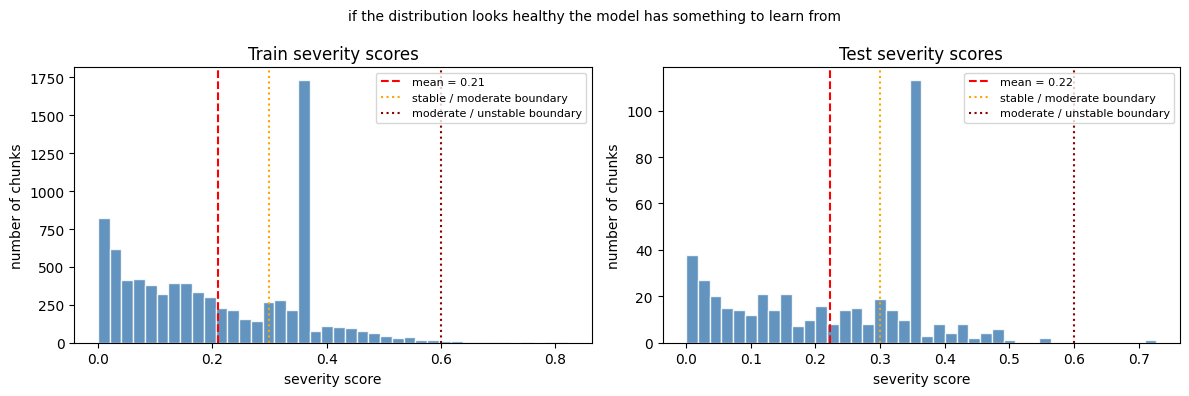

saved score_distribution.png


In [ ]:
# CHUNK 4- plot the score distribution before training

import numpy as np
import matplotlib.pyplot as plt

train_scores = np.array(split_ds["train"]["severity_score"], dtype=np.float32)
test_scores  = np.array(split_ds["test"]["severity_score"],  dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, title in [
    (axes[0], train_scores, "Train severity scores"),
    (axes[1], test_scores,  "Test severity scores"),
]:
    ax.hist(scores, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(float(scores.mean()), color="red",    linestyle="--", label=f"mean = {scores.mean():.2f}")
    ax.axvline(0.3,                  color="orange", linestyle=":",  label="stable / moderate boundary")
    ax.axvline(0.6,                  color="darkred",linestyle=":",  label="moderate / unstable boundary")
    ax.set_title(title)
    ax.set_xlabel("severity score")
    ax.set_ylabel("number of chunks")
    ax.legend(fontsize=8)

plt.suptitle("if the distribution looks healthy the model has something to learn from", fontsize=10)
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=120)
plt.show()
print("saved score_distribution.png")

In [ ]:
# CHUNK 5- model and training
#(stable/moderate/unstable)

import torch
import torch.nn as nn
import numpy as np
from scipy.stats import pearsonr
from transformers import AutoModelForAudioClassification, TrainingArguments, Trainer


def data_collator(features):
    batch = {}
    batch["input_values"] = torch.tensor(
        np.stack([np.array(f["input_values"]) for f in features]),
        dtype=torch.float32
    )
    if "attention_mask" in features[0]:
        batch["attention_mask"] = torch.tensor(
            np.stack([np.array(f["attention_mask"]) for f in features]),
            dtype=torch.long
        )
    batch["labels"] = torch.tensor(
        [float(f["severity_score"]) for f in features],
        dtype=torch.float32
    )
    return batch


def score_to_bucket(scores):
    buckets = np.zeros(len(scores), dtype=int)
    buckets[scores >= 0.30] = 1
    buckets[scores >= 0.60] = 2
    return buckets


def compute_metrics(eval_pred):
    raw_preds = eval_pred.predictions

    preds  = torch.sigmoid(
        torch.tensor(np.array(raw_preds, dtype=np.float32))
    ).numpy().reshape(-1)

    labels = np.array(eval_pred.label_ids, dtype=np.float32).reshape(-1)

    mae = float(np.abs(preds - labels).mean())

    if len(preds) > 1 and preds.std() > 1e-9 and labels.std() > 1e-9:
        pcc = float(pearsonr(preds, labels)[0])
    else:
        pcc = 0.0

    pred_buckets  = score_to_bucket(preds)
    label_buckets = score_to_bucket(labels)
    bucket_acc    = float((pred_buckets == label_buckets).mean())

    return {
        "mae"           : mae,
        "pearson"       : pcc,
        "bucket_accuracy": bucket_acc
    }


class PaceRegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits.squeeze(-1).float()
        preds   = torch.sigmoid(logits)
        loss    = nn.SmoothL1Loss(beta=0.1)(preds, labels.float())
        return (loss, outputs) if return_outputs else loss


print("loading wav2vec2-base with regression head...")
model = AutoModelForAudioClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels              = 1,
    ignore_mismatched_sizes = True,
)

model.wav2vec2.feature_extractor._freeze_parameters()
frozen = sum(p.numel() for p in model.wav2vec2.feature_extractor.parameters())
total  = sum(p.numel() for p in model.parameters())
print(f"frozen: {frozen:,}   trainable: {total - frozen:,}")
print("transformer layers + classifier head will be updated")

loading wav2vec2-base with regression head...


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


frozen: 4,200,448   trainable: 90,368,385
transformer layers + classifier head will be updated


In [ ]:
# CHUNK 6- train


training_args = TrainingArguments(
    output_dir                  = "./pace_model",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    learning_rate               = 2e-5,
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 4,
    num_train_epochs            = 5,
    warmup_ratio                = 0.05,
    weight_decay                = 0.01,
    lr_scheduler_type           = "cosine",
    logging_steps               = 10,
    report_to                   = "none",
    load_best_model_at_end      = True,
    metric_for_best_model       = "mae",
    greater_is_better           = False,
    remove_unused_columns       = False,
    group_by_length             = False,
)

trainer = PaceRegressionTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = split_ds["train"],
    eval_dataset    = split_ds["test"],
    compute_metrics = compute_metrics,
    data_collator   = data_collator,
)

print("training — sit back, this will take a while")
trainer.train()

final = trainer.evaluate()
print(f"\n{'='*50}")
print(f"  FINAL RESULTS")
print(f"  bucket accuracy : {final['eval_bucket_accuracy']:.2%}")
print(f"  MAE             : {final['eval_mae']:.4f}  (lower is better)")
print(f"  Pearson r       : {final['eval_pearson']:.4f}  (higher is better, max 1.0)")
print(f"{'='*50}")
print("bucket accuracy = % of chunks correctly classified as stable/moderate/unstable")

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


training — sit back, this will take a while


Epoch,Training Loss,Validation Loss,Mae,Pearson,Bucket Accuracy
1,0.126960,0.023382,0.049802,0.850921,0.883516
2,0.091314,0.024393,0.050467,0.839611,0.859341
3,0.072520,0.020333,0.044953,0.866699,0.879121
4,0.068086,0.018882,0.041579,0.883401,0.896703
5,0.049036,0.018714,0.041116,0.886590,0.901099


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  FINAL RESULTS
  bucket accuracy : 90.11%
  MAE             : 0.0411  (lower is better)
  Pearson r       : 0.8866  (higher is better, max 1.0)
bucket accuracy = % of chunks correctly classified as stable/moderate/unstable


running predictions on test set...



  ACCURACY (bucket): 90.11%
  MAE              : 0.0411
  Pearson r        : 0.8866


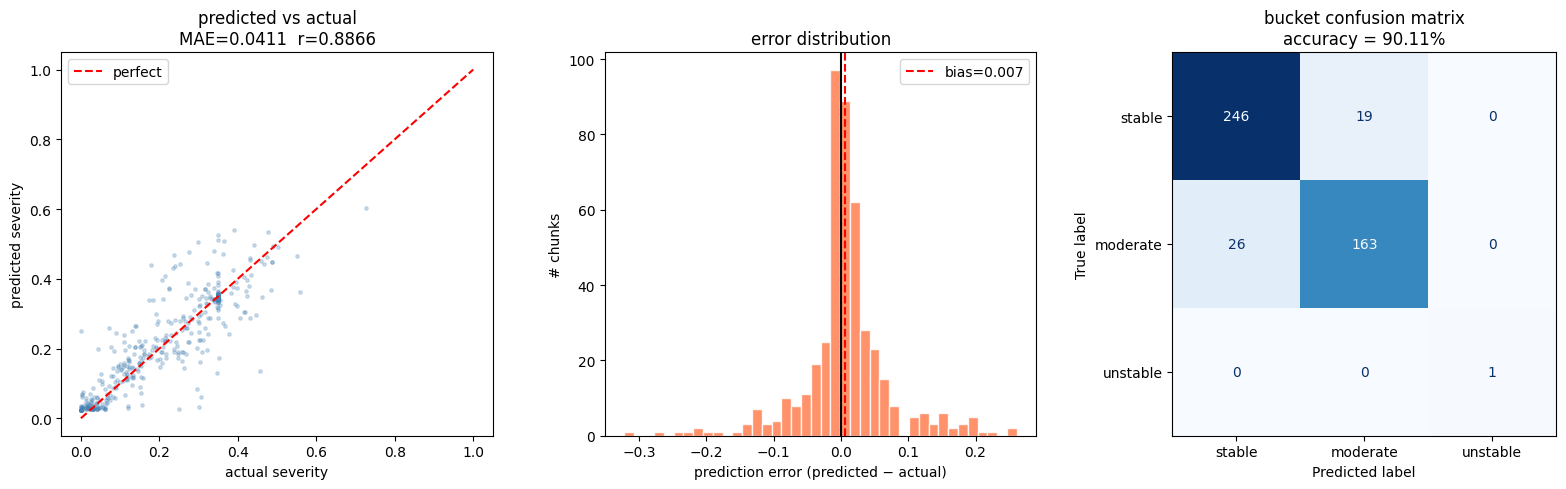


per-bucket classification report:
              precision    recall  f1-score   support

      stable       0.90      0.93      0.92       265
    moderate       0.90      0.86      0.88       189
    unstable       1.00      1.00      1.00         1

    accuracy                           0.90       455
   macro avg       0.93      0.93      0.93       455
weighted avg       0.90      0.90      0.90       455


sample predictions:
#      actual  predicted    error  verdict
--------------------------------------------------
1       0.262      0.263   +0.001  stable
2       0.179      0.440   +0.261  moderate
3       0.259      0.165   -0.094  stable
4       0.000      0.024   +0.024  stable
5       0.041      0.045   +0.004  stable
6       0.350      0.525   +0.175  moderate
7       0.107      0.106   -0.001  stable
8       0.350      0.341   -0.009  moderate
9       0.100      0.104   +0.004  stable
10      0.350      0.343   -0.007  moderate


In [ ]:
# CHUNK 7- full evaluation

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import pearsonr
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("running predictions on test set...")
pred_out = trainer.predict(split_ds["test"])

preds   = torch.sigmoid(
    torch.tensor(np.array(pred_out.predictions, dtype=np.float32))
).numpy().reshape(-1)

actuals = np.array(pred_out.label_ids, dtype=np.float32).reshape(-1)

mae = float(np.abs(preds - actuals).mean())
pcc = float(pearsonr(preds, actuals)[0]) if preds.std() > 1e-9 else 0.0

# bucket accuracy
pred_buckets  = score_to_bucket(preds)
label_buckets = score_to_bucket(actuals)
bucket_acc    = float((pred_buckets == label_buckets).mean())

print(f"  ACCURACY (bucket): {bucket_acc:.2%}")
print(f"  MAE              : {mae:.4f}")
print(f"  Pearson r        : {pcc:.4f}")

# plot 1 scatter predicted vs actual
# plot 2 error histogram
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(actuals, preds, alpha=0.25, s=6, color="steelblue")
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label="perfect")
axes[0].set_xlabel("actual severity")
axes[0].set_ylabel("predicted severity")
axes[0].set_title(f"predicted vs actual\nMAE={mae:.4f}  r={pcc:.4f}")
axes[0].legend()

errors = preds - actuals
axes[1].hist(errors, bins=40, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvline(0,                    color="black", linestyle="-",  linewidth=1.5)
axes[1].axvline(float(errors.mean()), color="red",   linestyle="--", label=f"bias={errors.mean():.3f}")
axes[1].set_xlabel("prediction error (predicted − actual)")
axes[1].set_ylabel("# chunks")
axes[1].set_title("error distribution")
axes[1].legend()

cm   = confusion_matrix(label_buckets, pred_buckets)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stable", "moderate", "unstable"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title(f"bucket confusion matrix\naccuracy = {bucket_acc:.2%}")

plt.tight_layout()
plt.savefig("pace_eval.png", dpi=120)
plt.show()

# classification report on buckets
print("\nper-bucket classification report:")
print(classification_report(label_buckets, pred_buckets,
                             target_names=["stable", "moderate", "unstable"]))

def severity_label(score):
    if score < 0.30: return "stable"
    if score < 0.60: return "moderate"
    return "unstable"

print(f"\nsample predictions:")
print(f"{'#':<4} {'actual':>8} {'predicted':>10} {'error':>8}  verdict")
print("-" * 50)
for i, (a, p) in enumerate(zip(actuals[:10], preds[:10])):
    print(f"{i+1:<4} {float(a):8.3f} {float(p):10.3f} {float(p-a):+8.3f}  {severity_label(float(p))}")

In [ ]:
# CHUNK 8- save the model

import os
import json

print("saving model...")
trainer.save_model("./pace_model_final")
feature_extractor.save_pretrained("./pace_model_final")

config = {
    "task"           : "speaking pace instability detection",
    "score_range"    : "0.0 (stable) to 1.0 (very unstable)",
    "bucket_labels"  : {"0.00-0.29": "stable", "0.30-0.59": "moderate", "0.60-1.00": "unstable"},
    "severity_weights": {
        "pause_cov"     : 0.30,
        "max_pause_norm": 0.25,
        "rush_ratio"    : 0.20,
        "wps_deviation" : 0.15,
        "burst_cov"     : 0.10
    },
    "constants" : {
        "target_wps"   : float(TARGET_WPS),
        "rush_wps"     : float(RUSH_WPS),
        "long_pause_s" : float(LONG_PAUSE_S),
        "sampling_rate": SR
    }
}
with open("./pace_model_final/pace_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("saved to ./pace_model_final")

saving model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to ./pace_model_final


In [ ]:
# CHUNK 9  inference on real podcast audio (PodcastFillers dataset)


import os
import json
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

SR_INF    = 16000
CHUNK_INF = SR_INF * 5
N_CLIPS   = 20

print("loading saved model...")
fe_inf    = AutoFeatureExtractor.from_pretrained("./pace_model_final")
model_inf = AutoModelForAudioClassification.from_pretrained("./pace_model_final")
model_inf.eval()

with open("./pace_model_final/pace_config.json") as f:
    pace_cfg = json.load(f)


def severity_label(score):
    if score < 0.30: return "stable"
    if score < 0.60: return "moderate"
    return "unstable"


def infer_clip(audio_array, sr):
    if sr != SR_INF:
        import torchaudio.functional as F_audio
        wav = torch.from_numpy(audio_array).unsqueeze(0)
        wav = F_audio.resample(wav, orig_freq=sr, new_freq=SR_INF)
        audio_array = wav.squeeze(0).numpy()

    audio    = np.array(audio_array, dtype=np.float32)
    clip_dur = len(audio) / SR_INF
    results  = []

    for start in range(0, len(audio), CHUNK_INF):
        chunk = audio[start : start + CHUNK_INF]
        if len(chunk) < CHUNK_INF:
            chunk = np.pad(chunk, (0, CHUNK_INF - len(chunk)))

        feats = fe_inf(
            [chunk],
            sampling_rate = SR_INF,
            max_length    = CHUNK_INF,
            truncation    = True,
            padding       = "max_length",
            return_tensors= "pt"
        )

        with torch.no_grad():
            logit = model_inf(**feats).logits

        score = float(torch.sigmoid(logit).item())

        t_s = start / SR_INF
        t_e = min(t_s + 5.0, clip_dur)
        results.append({
            "window": f"{t_s:.1f}s – {t_e:.1f}s",
            "score" : round(score, 3),
            "label" : severity_label(score),
        })

    clip_score = float(np.mean([r["score"] for r in results]))
    return results, clip_score, round(clip_dur, 2)


print("streaming PodcastFillers dataset...")
podcast_ds = load_dataset("bookbot/PodcastFillers-filtered", streaming=True)
try:
    stream = iter(podcast_ds["train"])
except KeyError:
    stream = iter(podcast_ds)

print(f"\npredicting on {N_CLIPS} real podcast clips\n")

for clip_num in range(N_CLIPS):
    try:
        sample = next(stream)
    except StopIteration:
        print("ran out of clips")
        break

    audio_array = np.array(sample["audio"]["array"], dtype=np.float32)
    sr          = int(sample["audio"]["sampling_rate"])

    results, clip_score, dur = infer_clip(audio_array, sr)

    bar_len = int(clip_score * 20)
    bar     = "█" * bar_len + "░" * (20 - bar_len)
    print(f"clip {clip_num+1:>2}  ({dur}s)  avg={clip_score:.3f}  [{bar}]  {severity_label(clip_score).upper()}")
    for r in results:
        flag = "!! " if r['label'] == 'unstable' else ("~  " if r['label'] == 'moderate' else "   ")
        print(f"  {flag}{r['window']:<18} score={r['score']:.3f}  {r['label']}")
    print()



loading saved model...


Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

streaming PodcastFillers dataset...


README.md:   0%|          | 0.00/889 [00:00<?, ?B/s]


predicting on 20 real podcast clips
clip  1  (11.1s)  avg=0.168  [███░░░░░░░░░░░░░░░░░]  STABLE
     0.0s – 5.0s        score=0.077  stable
     5.0s – 10.0s       score=0.077  stable
  ~  10.0s – 11.1s      score=0.350  moderate

clip  2  (26.01s)  avg=0.097  [█░░░░░░░░░░░░░░░░░░░]  STABLE
     0.0s – 5.0s        score=0.041  stable
     5.0s – 10.0s       score=0.089  stable
     10.0s – 15.0s      score=0.035  stable
     15.0s – 20.0s      score=0.033  stable
     20.0s – 25.0s      score=0.030  stable
  ~  25.0s – 26.0s      score=0.352  moderate

clip  3  (15.24s)  avg=0.040  [░░░░░░░░░░░░░░░░░░░░]  STABLE
     0.0s – 5.0s        score=0.073  stable
     5.0s – 10.0s       score=0.027  stable
     10.0s – 15.0s      score=0.035  stable
     15.0s – 15.2s      score=0.025  stable

clip  4  (14.28s)  avg=0.180  [███░░░░░░░░░░░░░░░░░]  STABLE
     0.0s – 5.0s        score=0.189  stable
     5.0s – 10.0s       score=0.147  stable
     10.0s – 14.3s      score=0.203  stable

clip  5 